# Comparison of False Discovery Results
Here, we can compare the results of multiple PIPP runs.
We need to specify the relative path to the results below.

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objs as go

df = pd.read_csv("../examples/example_data/fdr_multi_test_result2.csv")

'''
Specify here which domain to compare:
- "fdr_conf1": False Discovery Rate at Confidence Level 1
- "proportion_ft": Proportion of False Transfers to All Transfers
'''
domain_to_compare = 'fdr_conf1'

KeyboardInterrupt: 

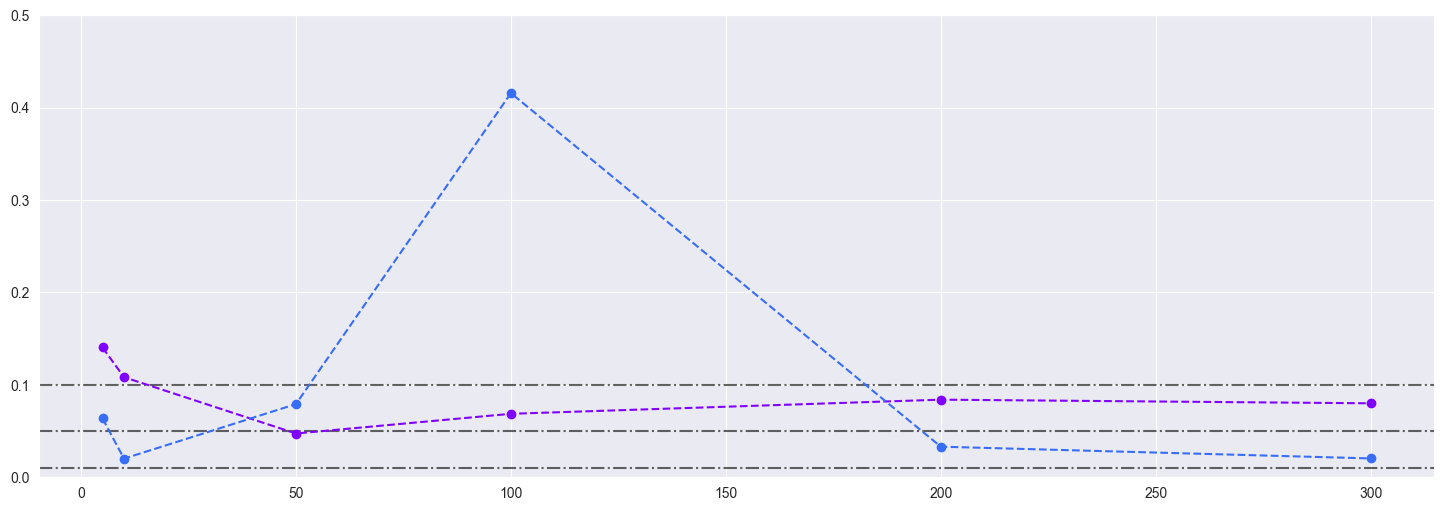

In [69]:
# x-axis: n_anchors, y-axis: fdr_conf1, group by: n_pc
unique_n_pc = df['n_pcs'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(18, 6))
plt.axhline(y=.01, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.05, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.1, color='black', linestyle='dashdot', alpha=0.6)
# Specify the upper limit of FDR to view:
plt.ylim(0,0.5 if domain_to_compare == 'fdr_conf1' else 100)

# Plot each line separately for each unique value in 'n_pc'
for i, n_pc in enumerate(unique_n_pc):
    subset_df = df[df['n_pcs'] == n_pc]
    mean_values = subset_df.groupby('n_anchors')[domain_to_compare].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'PCs: {int(n_pc)}' if n_pc>0 else "Without ESM", color=colors[i])

plt.xlabel('Number of Anchors', fontsize=20)
plt.xticks([5,10,50,100,200,300], [5,'\n10',50,100,200,300], fontsize=20)
#plt.autoscale(enable=True, axis='x')
plt.yticks(fontsize=20)
plt.ylabel('FDR at Confidence Level 1' if domain_to_compare=='fdr_conf1' else 'Percentage of False Transfers to All Transfers'
           , fontsize=20)
#plt.title('FDR at Confidence Level 1 for Number of Anchors grouped by PCs' if domain_to_compare=='fdr_conf1' else 'Percentage of False Transfers to All Transfers for Number of Anchors grouped by PCs', fontsize=20)
plt.legend(fontsize=16)

plt.show()

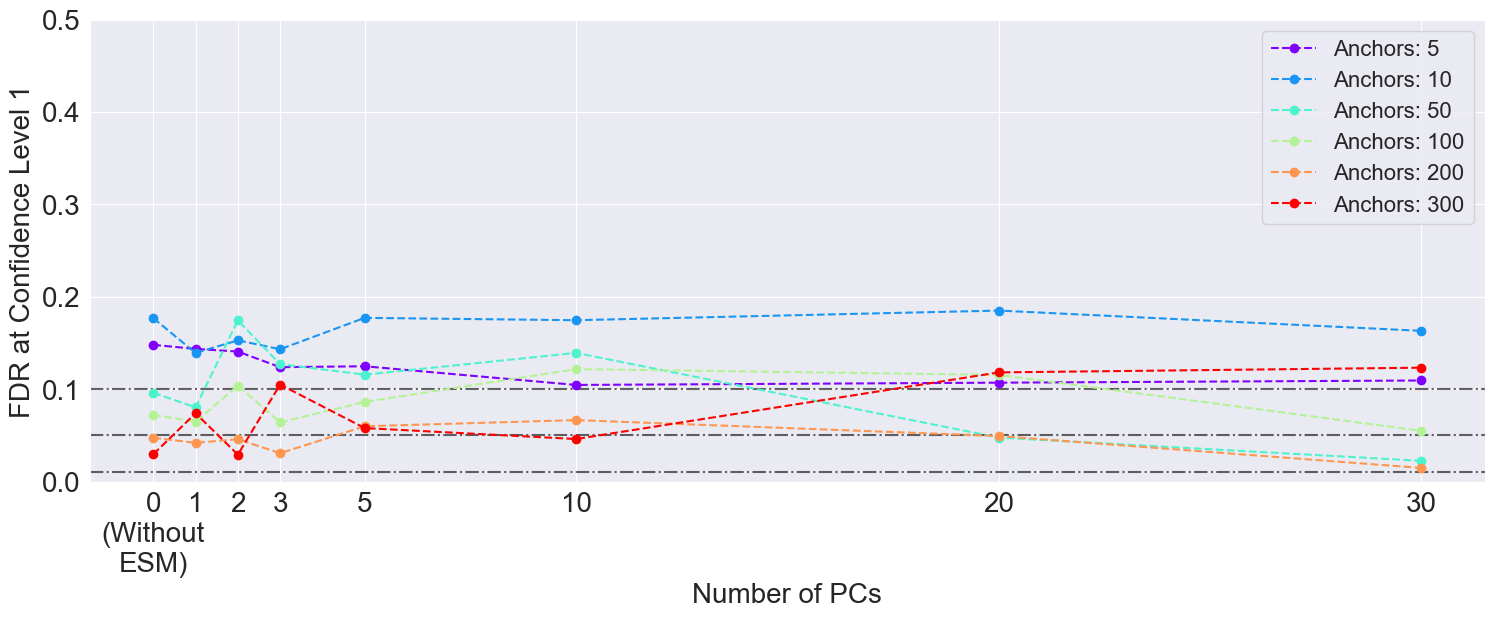

In [63]:
# x-axis: n_pc, y-axis: fdr_conf1, group by: n_anchors
unique_n_anchors = df['n_anchors'].unique()

colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_anchors)))

plt.figure(figsize=(18, 6))
plt.axhline(y=.01, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.05, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.1, color='black', linestyle='dashdot', alpha=0.6)
# Specify the upper limit of FDR to view:
plt.ylim(0,0.5 if domain_to_compare=='fdr_conf1' else 100)


# Plot each line separately for each unique value in 'n_pc'
for i, n_anchor in enumerate(unique_n_anchors):
    subset_df = df[df['n_anchors'] == n_anchor]
    mean_values = subset_df.groupby('n_pcs')[domain_to_compare].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'Anchors: {int(n_anchor)}', color=colors[i])

plt.xlabel('Number of PCs', fontsize=20)
plt.xticks([0,1,2,3,5,10,20,30],['0\n(Without\nESM)',1,2,3,5,10,20,30], fontsize=20) # ,2,5,10
plt.yticks(fontsize=20)
plt.ylabel('FDR at Confidence Level 1' if domain_to_compare=='fdr_conf1' else 'Percentage of False Transfers to All Transfers', fontsize=20)
#plt.title('FDR at Confidence Level 1 for Number of PCs grouped by Anchors' if domain_to_compare=='fdr_conf1' else 'Percentage of False Transfers to All Transfers for Number of PCs grouped by Anchors', fontsize=20)
plt.legend(fontsize=16)

plt.show()

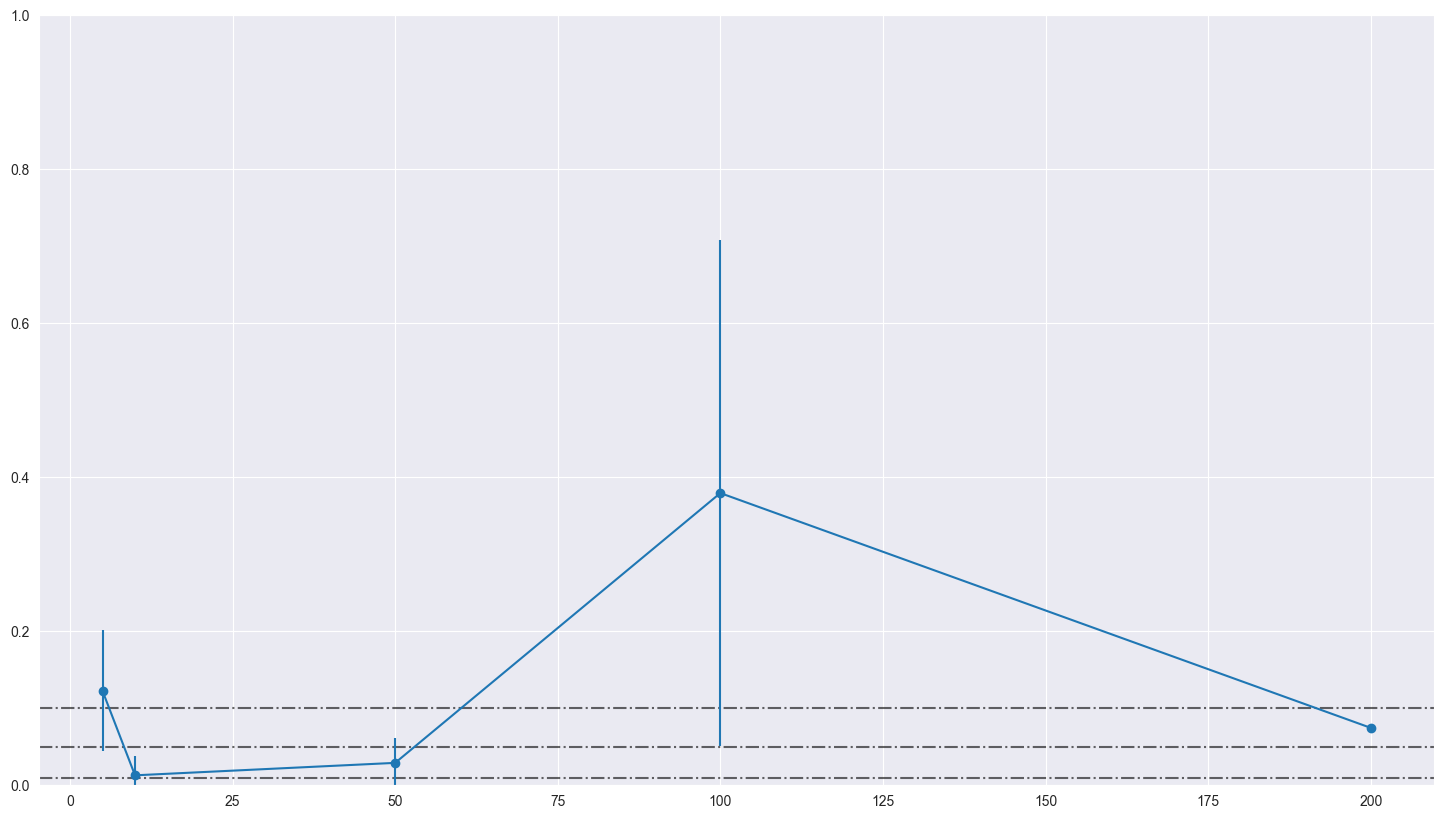

In [35]:
plt.figure(figsize=(18, 10))
plt.axhline(y=.01, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.05, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.1, color='black', linestyle='dashdot', alpha=0.6)
# Specify the upper limit of FDR to view:
plt.ylim(0,1 if domain_to_compare=='fdr_conf1' else 100)

filtered_df = df[(df['n_pcs'] == 30)] #  & (df['n_pc'] == 20)

mean_values = filtered_df.groupby('n_anchors').mean()

y_err = filtered_df.groupby('n_anchors')['fdr_conf1'].std()  # Example: Standard deviation of 'fdr' values

unique_n_pcs = filtered_df['n_anchors'].unique()

# Plot the data with error bars
plt.errorbar(unique_n_pcs, mean_values['fdr_conf1'], yerr=y_err, fmt='-o', label='Data with Error')
fig = plt.gcf()
fig.set_facecolor('white')
plt.show()

In [41]:
# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(x=df['n_anchors'], y=df['n_pcs'], z=df['fdr_conf1'], mode='markers')])
fig.update_layout(scene=dict(aspectmode='cube',
                             xaxis=dict(title='Number of Anchors'),
                             yaxis=dict(title='Number of PCs'),
                             zaxis=dict(title='FDR at Confidence Level 1')),
                  title='3D Scatter Plot',
                  width=800, 
                  height=800)
fig.show()

KeyboardInterrupt: 

In [9]:
# Create 3D surface plot
df_agg = df.groupby(['n_anchors', 'n_pcs']).mean().reset_index()

# Reshape the DataFrame into a grid
x_vals = sorted(df_agg['n_anchors'].unique())
y_vals = sorted(df_agg['n_pcs'].unique())
z_vals = df_agg.pivot(index='n_anchors', columns='n_pcs', values='fdr_conf1').values

# Create the surface plot
fig = go.Figure(data=[go.Surface(z=z_vals, x=x_vals, y=y_vals)])

# Update layout with axis labels and title
fig.update_layout(scene=dict(xaxis_title='Number of Anchors',
                             yaxis_title='Number of PCs',
                             zaxis_title='FDR at Confidence Level 1'),
                  title='3D Surface Plot',
                  width=800, 
                  height=800)

fig.show()